In [4]:
# from Class_PAS_Data_Extract import PASDataEngine
# 

In [5]:
import pandas as pd

In [6]:
def read_excel_to_dataframe(file_path, sheet_name, halt_on_error=True):
    """
    Reads a specific worksheet from an Excel file into a Pandas DataFrame.

    Parameters:
    - file_path (str): The path to the Excel file.
    - sheet_name (str or int): The name or index of the worksheet to load.
    - halt_on_error (bool): Flag indicating whether to halt execution on error.
                            If False, the function will return None on error.

    Returns:
    - DataFrame or None: The DataFrame if successful, or None if an error occurs and halt_on_error is False.
    """
    try:
        # Attempt to read the specified worksheet into a DataFrame
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        return df
    except Exception as e:
        # Handle the error based on the halt_on_error flag
        if halt_on_error:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}")
            raise  # Re-raise the exception to halt execution
        else:
            print(f"Error reading {file_path}, sheet {sheet_name}: {e}. Returning None.")
            return None



In [7]:
config_file = r'\\azshfs.intel.com\AZAnalysis$\1272_MAODATA\Config\PDE\dagarcia\PAS_CONFIG\P1275_Config.xlsx'

pas_config = read_excel_to_dataframe(config_file, 'PlotConfig', halt_on_error=True)
email_config = read_excel_to_dataframe(config_file, 'EmailConfig', halt_on_error=True)
reticle_config = read_excel_to_dataframe(config_file, 'ReticleConfig', halt_on_error=False)

In [8]:
if  pas_config is not None:
    unique_combos = pas_config.groupby(['PRODUCT', 'FAB_PROD', 'RET_PROD'])['COMMIT'].max().reset_index()

    products = unique_combos.set_index('PRODUCT').to_dict(orient='index')
    
    for product, details in products.items():
        print(f"Processing Product: {product}")
        print(f"FAB_PROD: {details['FAB_PROD']}, RET_PROD: {details['RET_PROD']}, COMMIT: {details['COMMIT']}")



Processing Product: Sundance Mesa 1
FAB_PROD: 8PWQCVA, RET_PROD: 8PWQCA, COMMIT: 2025-07-28 18:00:00


In [9]:
# products['Sundance Mesa 1']
pas_config

,PRODUCT,TITLE,LOT,COMMIT,FAB_PROD,RET_PROD,ORIG_COMMIT
0,Sundance Mesa 1,Lead Lot,L5138740,2025-07-28 18:00:00,8PWQCVA,8PWQCA,2025-08-14
1,Sundance Mesa 1,Scout 1,L5139550,2025-07-27 18:00:00,8PWQCVA,8PWQCA,2025-08-04
2,Sundance Mesa 1,Scout 2,L5139560,2025-07-27 18:00:00,8PWQCVA,8PWQCA,2025-08-04


In [10]:
dataengine = PASDataEngine()

In [11]:

prod = Product('8PWQCA', products['Sundance Mesa 1'],  dataengine, ret_version=reticle_config, lots=None, debug_flag=True)

C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\2563407304.py:92: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\3809738507.py:119: FutureWarning: The provided callable <function min at 0x0000022F385A0D60> is currently using DataFrameGroupBy.min. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "min" instead.
  RetData = pd.pivot_table(RetData,index=['LAYER'], values=['TAPEIN_TREND','ITO_TREND','FAB_REQUIREDDATE','IMO_TREND','SHIPDATE'], aggfunc=np.min).reset_index()


In [12]:
prod.add_lot('L5138740', 'Lead Lot')
prod.add_lot('L5139550', 'Scout 1')
prod.add_lot('L5139560', 'Scout 2')

C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\2563407304.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\2563407304.py:114: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\2563407304.py:41: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\2563407304.py:114: UserWarning: pa

In [13]:
prod.build_plot_data()


Difference in days: 160 days
Rounded difference: 161.0 days
ymin_date: 2025-02-22 00:00:00
ymin_val: 0
ymax_date: 2025-08-02 00:00:00
ymax_val: 161.0


In [14]:

plotdata = prod.plot_data
ymin_date = prod.ymin_date
ymax_date = prod.ymax_date
ymin_val = prod.ymin_val
ymax_val = prod.ymax_val
plotdata

,LAYER,EXEC_SEQ,TI,TO,ESD,SHIP,FRD,NPI PLAN,Lead Lot TREND,Lead Lot ACTUAL,Scout 1 TREND,Scout 1 ACTUAL,Scout 2 TREND,Scout 2 ACTUAL
0,START,1.0,0.0,0.0,0.0,0.0,0.0,2025-04-03 01:38:14.607449856,2025-03-24 17:55:06.000000000,2025-03-24 17:55:06,2025-03-24 17:55:07.000000000,2025-03-24 17:55:07,2025-03-24 17:55:06.000000000,2025-03-24 17:55:06
1,DCB,25.0,13.0,5.0,0.0,8.0,29.0,2025-04-03 21:45:07.214899712,2025-04-02 05:31:22.000000000,2025-04-02 05:31:22,2025-03-27 04:50:18.000000000,2025-03-27 04:50:18,2025-03-27 07:23:51.000000000,2025-03-27 07:23:51
2,DN1,81.0,13.0,5.0,0.0,7.0,29.0,2025-04-05 13:58:52.429799426,2025-04-04 21:37:44.000000000,2025-04-04 21:37:44,2025-03-29 17:37:43.000000000,2025-03-29 17:37:43,2025-03-29 13:45:46.000000000,2025-03-29 13:45:46
3,DN2,98.0,13.0,5.0,0.0,8.0,29.0,2025-04-06 02:02:59.994269340,2025-04-05 06:00:07.000000000,2025-04-05 06:00:07,2025-03-30 03:38:11.000000000,2025-03-30 03:38:11,2025-03-30 02:34:44.000000000,2025-03-30 02:34:44
4,DN3,115.0,13.0,5.0,0.0,8.0,29.0,2025-04-06 14:07:07.558739254,2025-04-05 19:40:30.000000000,2025-04-05 19:40:30,2025-03-31 11:23:34.000000000,2025-03-31 11:23:34,2025-03-30 23:15:49.000000000,2025-03-30 23:15:49
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97,CE3,2458.0,13.0,11.0,0.0,9.0,92.0,2025-07-25 17:10:44.177650428,2025-07-20 22:31:19.160458426,NaT,2025-07-20 04:33:46.661891087,NaT,2025-07-20 11:53:38.661891087,NaT
98,GV0,2473.0,13.0,11.0,0.0,10.0,93.0,2025-07-26 13:17:36.785100286,2025-07-21 18:38:11.767908282,NaT,2025-07-21 01:42:32.736389654,NaT,2025-07-21 09:02:24.736389654,NaT
99,GM1,2498.0,13.0,11.0,0.0,10.0,93.0,2025-07-28 01:29:59.478510028,2025-07-23 06:50:34.461318024,NaT,2025-07-22 15:46:19.670487075,NaT,2025-07-22 23:06:11.670487075,NaT
100,GV1,2522.0,13.0,33.0,0.0,12.0,93.0,2025-07-29 17:43:44.693409742,2025-07-24 23:04:19.676217737,NaT,2025-07-24 10:03:51.819484209,NaT,2025-07-24 17:23:43.819484209,NaT


C:\Users\dagarcia\AppData\Local\Temp\ipykernel_12772\4151307664.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)


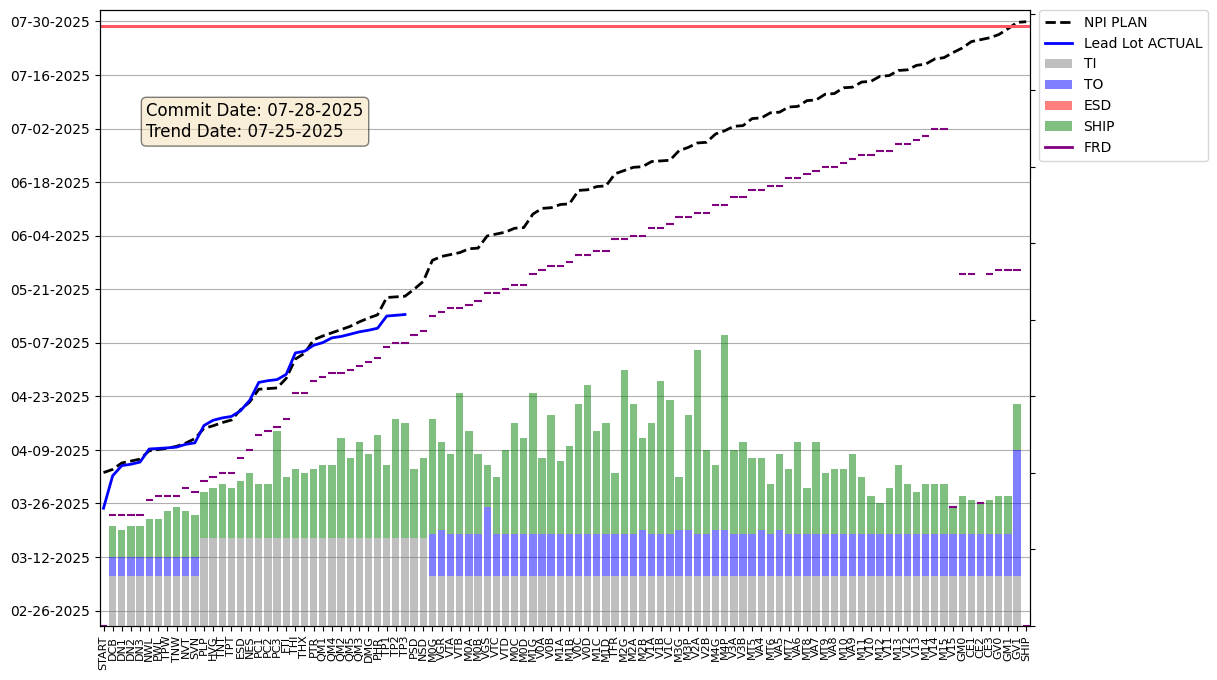

In [15]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D



commit_date = prod.commit
trend_date = plotdata['Lead Lot TREND'].max()
fig, ax1 = plt.subplots(figsize=(12, 8))

ax1.plot(plotdata['LAYER'], plotdata['NPI PLAN'],color='black', label='NPI PLAN', linewidth=2, linestyle='--')

# ax1.plot(plotdata['LAYER'], plotdata['Lead Lot TREND'],color='blue', label='Lead Lot TREND', linewidth=2, linestyle='--')  
ax1.plot(plotdata['LAYER'], plotdata['Lead Lot ACTUAL'],color='blue', label='Lead Lot ACTUAL', linewidth=2)
ax2 = ax1.twinx()

# bottom = plotdata['BaseLine']

bar_colors = ['grey','blue', 'red', 'green', '#A0EBFF']
bar_columns = ['TI', 'TO', 'ESD', 'SHIP']

ax1.axhline(y=commit_date, color='#FF5662', linestyle='-', linewidth=2)

plotdata['BOTTOM'] = 0
for idx, bar in enumerate(bar_columns):
    # if idx==0:
        # ax2.bar(plotdata['LAYER'], plotdata[bar], label=bar, color=bar_colors[idx], alpha=0.5)
    # else:
        # ax2.bar(plotdata['LAYER'], plotdata[bar], bottom=plotdata[bar_columns[idx-1]], label=bar, color=bar_colors[idx], alpha=0.5)
    ax2.bar(plotdata['LAYER'], plotdata[bar], bottom=plotdata['BOTTOM'], label=bar, color=bar_colors[idx], alpha=0.5)
    plotdata['BOTTOM'] = plotdata[bar] + plotdata['BOTTOM']


for bar,frd in zip(plt.gca().patches,plotdata['FRD']):
    x = bar.get_x() + bar.get_width() / 2
    ax2.hlines(frd, x-bar.get_width()/2, x+bar.get_width()/2, color='purple')

ax1.set_ylim(ymin_date, ymax_date)
ax2.set_ylim(ymin_val, ymax_val)

fig.patch.set_facecolor('white')

# Add a text box in the upper left
textstr = f'Commit Date: {commit_date.strftime("%m-%d-%Y")}'
textstr += f'\nTrend Date: {trend_date.strftime("%m-%d-%Y")}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
ax1.text(0.05, 0.85, textstr, transform=ax1.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='left', bbox=props)

# Set the background color of the axes (the plot area) to white
ax1.set_facecolor('white')
ax2.set_facecolor('white')

ax1.set_xticklabels(plotdata['LAYER'], rotation=90, fontsize=8)
ax2.set_yticklabels([])
ax1.margins(x=0)
ax1.yaxis.grid(True)
ax1.yaxis.set_major_locator(mdates.DayLocator(interval=14)) 
ax1.yaxis.set_major_formatter(mdates.DateFormatter('%m-%d-%Y'))
ax1.axhline(y=commit_date, color='#FF5662', linestyle='-', linewidth=2)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
frd_line = Line2D([0], [0], linestyle='-', color='purple', linewidth=2, label='FRD')

handles = handles1 + handles2 + [frd_line]
labels = labels1 + labels2 + ['FRD']
plt.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.01,1),borderaxespad=0.)

In [18]:
test = prod.base_flow
test

,NPI,FAB_PROD,LAYER,CUM_ACTIVITY,EXEC_SEQ,ACT
0,8PWQCA,8PWQCVA,START,0,1.0,NaN
1,8PWQCA,8PWQCVA,DCB,5,25.0,5.0
2,8PWQCA,8PWQCVA,DN1,15,81.0,10.0
3,8PWQCA,8PWQCVA,DN2,18,98.0,3.0
4,8PWQCA,8PWQCVA,DN3,21,115.0,3.0
...,...,...,...,...,...,...
94,8PWQCA,8PWQCVA,VAG,662,2408.0,7.0
95,8PWQCA,8PWQCVA,VAC,672,2432.0,10.0
96,8PWQCA,8PWQCVA,GM1,692,2498.0,20.0
97,8PWQCA,8PWQCVA,GV1,702,2522.0,10.0
